In [18]:

# CUSTOMER CHURN PREDICTION SYSTEM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [19]:
df = pd.read_csv("C:/Users/akshay/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [20]:
# Display first 5 rows
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [21]:

print("\nDataset Information")
print(df.info())

print("\nShape of Dataset")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop Customer ID
df.drop("customerID", axis=1, inplace=True)


C:\Users\akshay\AppData\Local\Temp\ipykernel_16588\1917015907.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [23]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

print("\nEncoded Dataset")
print(df.head())


Encoded Dataset
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1

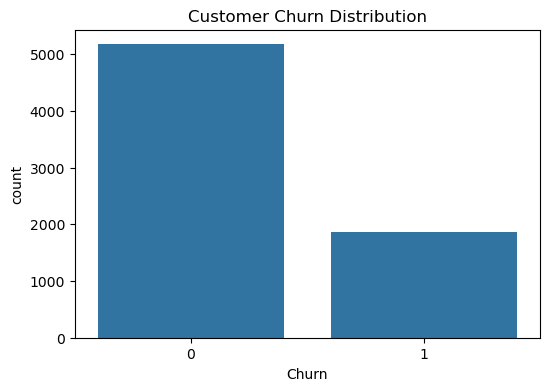

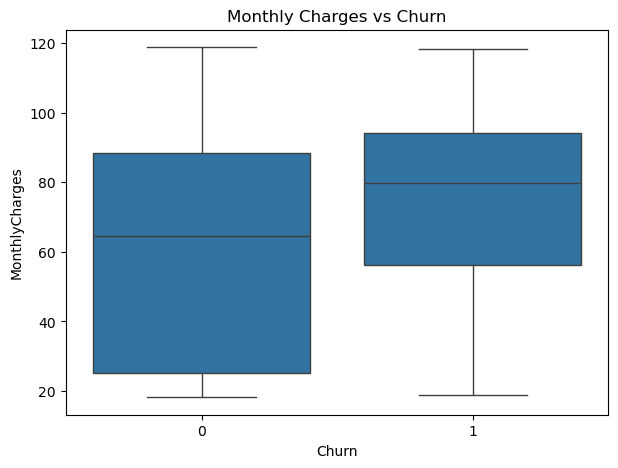

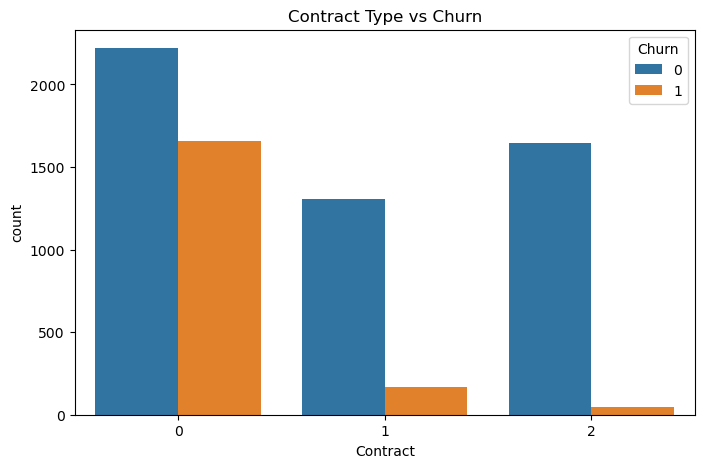

In [25]:

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

In [26]:

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

C:\Users\akshay\desktop\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [31]:
# 11. XGBoost
# ==============================
!pip install xgboost
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [32]:
def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision:", precision_score(y_true, y_pred))

    print("Recall   :", recall_score(y_true, y_pred))

    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred))


In [33]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("XGBoost", y_test, xgb_pred)

Logistic Regression
Accuracy : 0.8161816891412349
Precision: 0.6792452830188679
Recall   : 0.579088471849866
F1 Score : 0.6251808972503617

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Random Forest
Accuracy : 0.7955997161107168
Precision: 0.6591760299625468
Recall   : 0.4718498659517426
F1 Score : 0.55

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

XGBoost
Accuracy : 0.7920511000709723
P

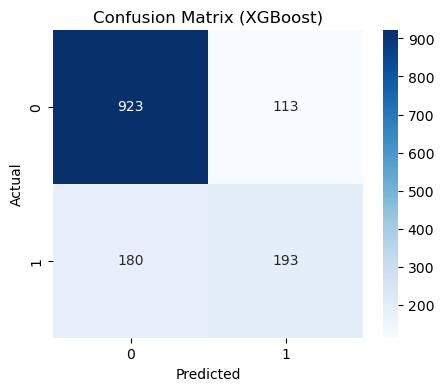

In [34]:

plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


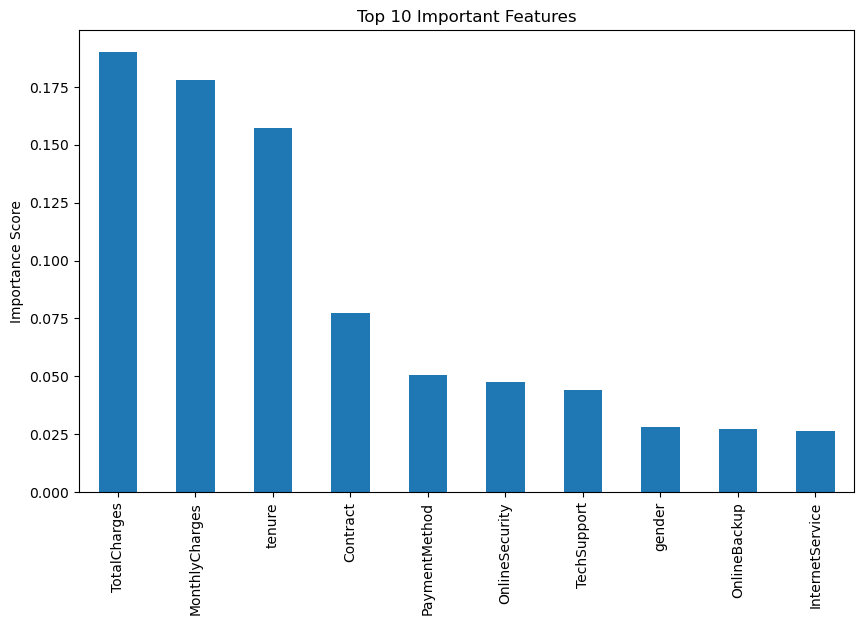

In [35]:

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))


importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.ylabel("Importance Score")
plt.show()


Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.816182
1        Random Forest  0.795600
2              XGBoost  0.792051


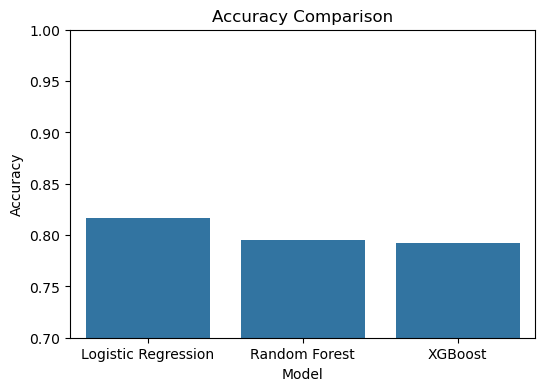

In [36]:

models = ["Logistic Regression", "Random Forest", "XGBoost"]

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

print("\nModel Comparison")
print(comparison)

plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Accuracy Comparison")

plt.ylim(0.70,1.0)

plt.show()

In [37]:
# Predict on New Customer

sample_customer = X.iloc[[0]]

prediction = xgb.predict(sample_customer)

if prediction[0] == 1:
    print("\nPrediction : Customer Will Churn")
else:
    print("\nPrediction : Customer Will Stay")


Prediction : Customer Will Churn
